In [1]:
#How gender,test preparations and parental education is impacting students score

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
#Load the dataset
df = pd.read_csv('/content/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,none,44,41,40
1,female,group D,high school,free/reduced,completed,57,59,93
2,male,group E,associate's degree,standard,completed,67,40,94
3,male,group D,master's degree,standard,completed,81,76,90
4,male,group E,bachelor's degree,free/reduced,completed,61,48,79


In [4]:
#Basic info
df.shape

(200, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       200 non-null    object
 1   race/ethnicity               200 non-null    object
 2   parental level of education  200 non-null    object
 3   lunch                        200 non-null    object
 4   test preparation course      200 non-null    object
 5   math score                   200 non-null    int64 
 6   reading score                200 non-null    int64 
 7   writing score                200 non-null    int64 
dtypes: int64(3), object(5)
memory usage: 12.6+ KB


In [7]:
#create total and average scores using numpy
df['total_score'] = np.sum(df[['math score','reading score','writing score']].values,axis=1)

In [8]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
0,male,group A,high school,standard,none,44,41,40,125
1,female,group D,high school,free/reduced,completed,57,59,93,209
2,male,group E,associate's degree,standard,completed,67,40,94,201
3,male,group D,master's degree,standard,completed,81,76,90,247
4,male,group E,bachelor's degree,free/reduced,completed,61,48,79,188


In [9]:
df['average_score'] = np.mean(df[['math score','reading score','writing score']].values,axis=1)

In [10]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,male,group A,high school,standard,none,44,41,40,125,41.666667
1,female,group D,high school,free/reduced,completed,57,59,93,209,69.666667
2,male,group E,associate's degree,standard,completed,67,40,94,201,67.000000
3,male,group D,master's degree,standard,completed,81,76,90,247,82.333333
4,male,group E,bachelor's degree,free/reduced,completed,61,48,79,188,62.666667


In [11]:
#Group by gender
df.groupby("gender")['average_score'].mean()

,average_score
gender,
female,69.306667
male,69.023333


In [12]:
#group by parental education
df.groupby("parental level of education")['average_score'].mean()

,average_score
parental level of education,
associate's degree,67.555556
bachelor's degree,65.858333
high school,70.656250
master's degree,73.160494
some college,69.648148
some high school,69.113821


In [13]:
#average math score by parental education
df.groupby("parental level of education")['math score'].mean()

,math score
parental level of education,
associate's degree,66.333333
bachelor's degree,63.900000
high school,67.968750
master's degree,71.370370
some college,71.222222
some high school,71.512195


In [20]:
df.groupby("test preparation course")['average_score'].mean()

,average_score
test preparation course,
completed,69.648649
none,68.561798


<Axes: xlabel='gender', ylabel='average_score'>

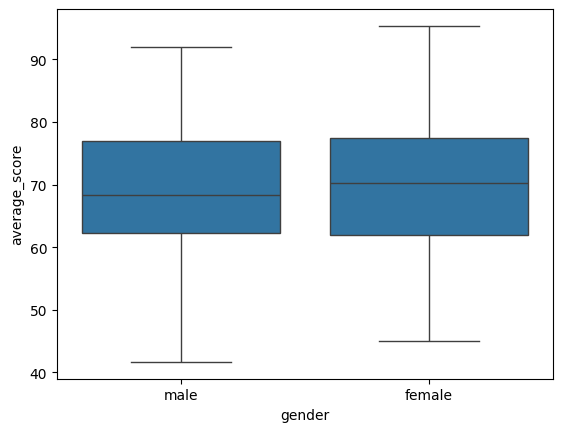

In [14]:
#Data visualization
#score distribution by gender
sns.boxplot(x='gender',y='average_score',data=df)

<Axes: xlabel='math score', ylabel='reading score'>

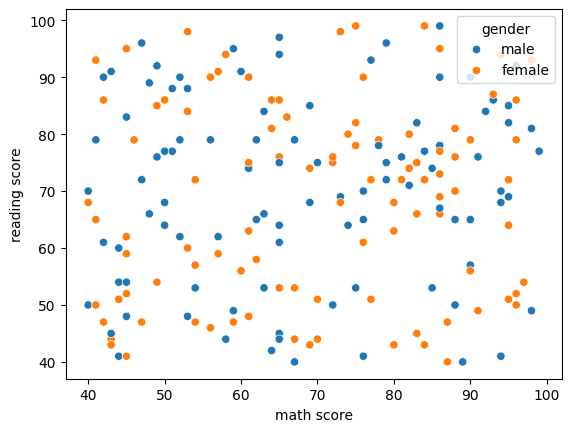

In [15]:
#Math score vs Reading score
sns.scatterplot(x='math score',y = 'reading score',hue='gender',data=df)

<Axes: xlabel='parental level of education', ylabel='average_score'>

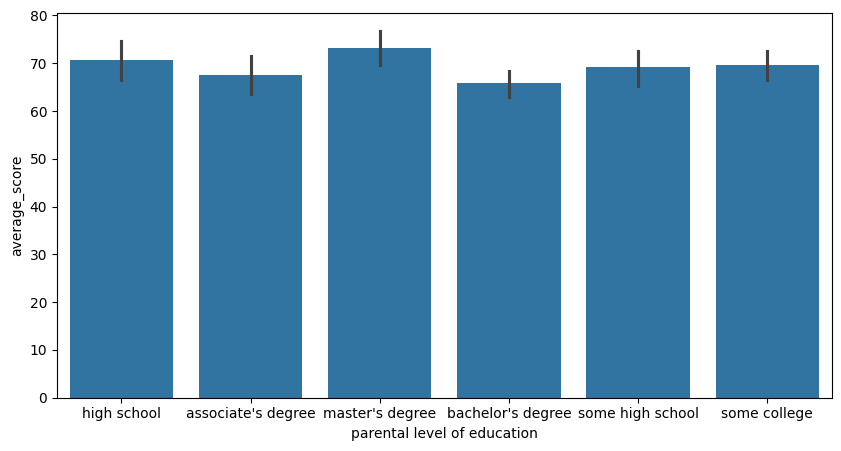

In [16]:
#Average score by parental education
plt.figure(figsize=(10,5))
sns.barplot(x='parental level of education',y='average_score',data=df)

<Axes: >

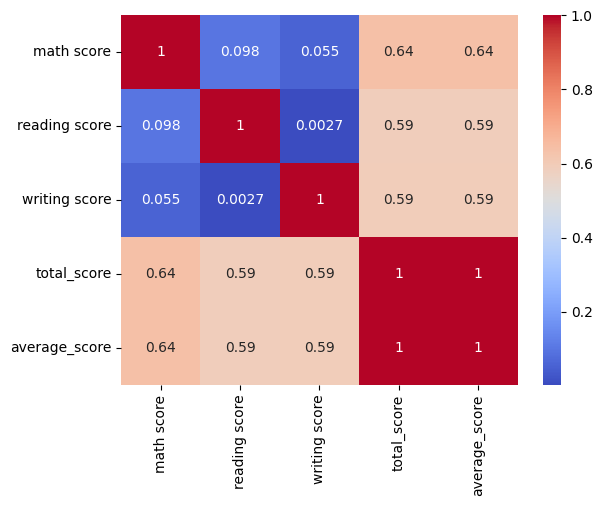

In [17]:
#correlation
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap='coolwarm')

In [ ]:
#Conclusion
#Female students scored higher on average
#Higher parental education levels are assocatioted with better student performance
#Students who completed test prep course generally performed well